# 01 · Target & mechanism of action (genomics / chemical biology layer)

**Goal:** establish, from curated bioactivity data, *how* rapamycin acts — the molecular
foundation for every downstream omics signature.

Rapamycin (sirolimus) binds **FKBP1A (FKBP12)**; the rapamycin–FKBP12 complex inhibits
**mTOR** within mTORC1. This notebook pulls rapamycin's targets, mechanism, and potency
from **ChEMBL**, then defines the mTOR-pathway gene set reused in notebooks 02/04/05.

In [1]:
import os, sys, json, gzip, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

# Resolve project root whether run from notebooks/ or project root.
CWD = Path.cwd()
PROJ = CWD.parent if CWD.name == "notebooks" else CWD
RAW = PROJ / "data" / "raw"
PROC = PROJ / "data" / "processed"
FIG = PROJ / "figures"
for d in (RAW, PROC, FIG):
    d.mkdir(parents=True, exist_ok=True)

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")
print("Project root:", PROJ)

Project root: /Users/jinmo/Documents/GitHub/Series1/Jin001_Docking/rapamycin_multiomics


In [2]:
import requests
CHEMBL = "https://www.ebi.ac.uk/chembl/api/data"

def chembl_get(path, **params):
    params.setdefault("format", "json")
    return requests.get(f"{CHEMBL}/{path}", params=params, timeout=60).json()

mol = chembl_get("molecule/CHEMBL413.json")
print("Compound:", mol["pref_name"], "| CHEMBL413")
print("Max clinical phase:", mol.get("max_phase"), "(4 = approved drug)")
props = mol.get("molecule_properties") or {}
print("MW: %s  | ALogP: %s  | first approval: %s" %
      (props.get("full_mwt"), props.get("alogp"), mol.get("first_approval")))

Compound: SIROLIMUS | CHEMBL413
Max clinical phase: 4.0 (4 = approved drug)
MW: 914.19  | ALogP: 6.18  | first approval: 1999


## 1 · Mechanism of action (curated)

In [3]:
moa = chembl_get("mechanism.json", molecule_chembl_id="CHEMBL413", limit=50)
moa_df = pd.json_normalize(moa["mechanisms"])
cols = [c for c in ["mechanism_of_action","target_chembl_id","action_type","max_phase"] if c in moa_df.columns]
display(moa_df[cols] if not moa_df.empty else moa_df)

# Resolve target names
for tid in moa_df.get("target_chembl_id", pd.Series(dtype=str)).dropna().unique():
    t = chembl_get(f"target/{tid}.json")
    print(tid, "->", t.get("pref_name"), "|", t.get("organism"))

,mechanism_of_action,target_chembl_id,action_type,max_phase
0,FK506-binding protein 1A inhibitor,CHEMBL1902,INHIBITOR,4


CHEMBL1902 -> Peptidyl-prolyl cis-trans isomerase FKBP1A | Homo sapiens


## 2 · Binding potency against FKBP1A and MTOR

In [4]:
# Pull activities for rapamycin against its two key human targets.
TARGETS = {"FKBP1A": "CHEMBL2581", "MTOR": "CHEMBL2842"}
records = []
for gene, tid in TARGETS.items():
    act = chembl_get("activity.json", molecule_chembl_id="CHEMBL413",
                     target_chembl_id=tid, limit=200)
    for a in act.get("activities", []):
        if a.get("standard_value") and a.get("standard_type") in ("IC50","Kd","Ki","EC50","Potency"):
            records.append(dict(gene=gene, type=a["standard_type"],
                                value=float(a["standard_value"]),
                                units=a.get("standard_units"),
                                assay=a.get("assay_description","")[:60]))
act_df = pd.DataFrame(records)
print("Activity measurements retrieved:", len(act_df))
if not act_df.empty:
    nm = act_df[act_df.units == "nM"]
    summary = nm.groupby(["gene","type"])["value"].median().reset_index()
    display(summary)
act_df.head(10)

Activity measurements retrieved: 20


,gene,type,value
0,MTOR,IC50,3.467
1,MTOR,Kd,0.600


,gene,type,value,units,assay
0,MTOR,IC50,3.467,nM,The inhibitory activity by using FK506 binding...
1,MTOR,IC50,0.450,nM,Inhibitory concentration against FKBP12 receptor
2,MTOR,IC50,1.600,nM,Inhibitory activity against FKBP12
3,MTOR,IC50,0.100,nM,Inhibition of mTOR kinase expressed in human H...
4,MTOR,IC50,10.000,nM,Inhibition of mTOR-mediated S6 phosphorylation...
5,MTOR,IC50,10000.000,nM,Inhibition of mTOR-mediated Akt phosphorylatio...
6,MTOR,IC50,430.000,nM,Inhibition of mTOR (unknown origin) incubated ...
7,MTOR,Kd,0.600,nM,Binding affinity to mTOR FKBP12 site (unknown ...
8,MTOR,IC50,0.100,nM,Inhibition of mTOR in HEK293 cells
9,MTOR,IC50,0.800,nM,Inhibition of mTOR (unknown origin)


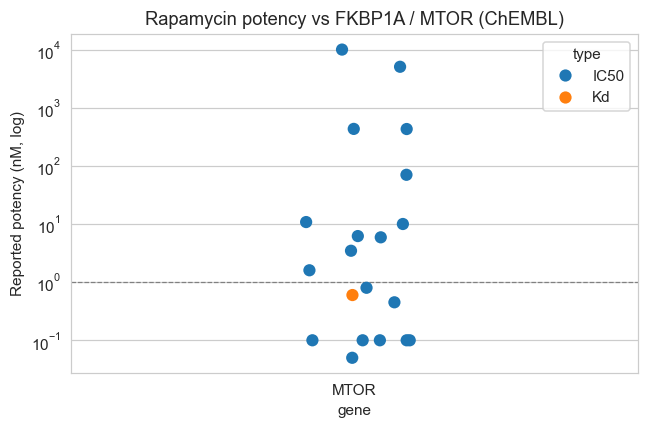

In [5]:
# Visualise potency (nM, log scale) against both targets.
if not act_df.empty and (act_df.units == "nM").any():
    nm = act_df[act_df.units == "nM"]
    fig, ax = plt.subplots(figsize=(6,4))
    sns.stripplot(data=nm, x="gene", y="value", hue="type", size=8, ax=ax)
    ax.set_yscale("log"); ax.set_ylabel("Reported potency (nM, log)")
    ax.set_title("Rapamycin potency vs FKBP1A / MTOR (ChEMBL)")
    ax.axhline(1, ls="--", c="grey", lw=.8)
    plt.tight_layout(); plt.savefig(FIG/"01_rapamycin_potency.png", dpi=150); plt.show()
else:
    print("No nM activities to plot (ChEMBL coverage varies).")

## 3 · Define the mTOR / mTORC1 gene set

A curated mTORC1-signalling gene set (target + canonical effectors / readouts) used
downstream to ask whether the transcriptome and proteome move consistently with mTOR
inhibition.

In [6]:
MTOR_PATHWAY = {
    # Drug target & complex
    "FKBP1A","MTOR","RPTOR","MLST8","AKT1S1","DEPTOR",
    # Translation initiation / cap-dependent translation (mTORC1 ↑ targets)
    "EIF4EBP1","EIF4E","EIF4G1","RPS6KB1","RPS6","EIF4B",
    # Ribosome biogenesis
    "RRN3","POLR1A","MYC",
    # Upstream regulators
    "TSC1","TSC2","RHEB","AKT1","PIK3CA","PTEN","STK11","PRKAA1",
    # Autophagy (mTORC1 ↓ suppresses; inhibition ↑ autophagy)
    "ULK1","ATG13","SQSTM1","MAP1LC3B","TFEB","ATG7",
    # Lipid / lysosome
    "SREBF1","LAMTOR1","RRAGA","RRAGC",
}
pd.Series(sorted(MTOR_PATHWAY)).to_csv(PROC/"mtor_pathway_genes.csv", index=False, header=["gene"])
print(f"mTOR pathway gene set: {len(MTOR_PATHWAY)} genes -> saved.")

mTOR pathway gene set: 33 genes -> saved.


**Takeaway.** Rapamycin is an approved drug (max phase 4) whose curated mechanism is
*mTOR inhibition via FKBP12 binding*, with sub-/low-nanomolar potency. Every downstream
omics layer is interpreted against this mechanism.